# `uncertain_expansion` — published production economies, solved with no manual input

The engine in `v2/` is the book's expansion code (the robust steady-state variant) with an entry that derives its own starting point (`auto_guess.py`, a 9-line patch) and a driver (`autosolve.py`) that verifies every returned steady state against the model's own equations — and, where the paper provides one, against the paper's own closed-form steady-state restrictions. `v2/PROVENANCE.md` lists every difference from the branch copy.

**Six economies.** Two from the book (the Section 11.7 AK economy and the computation appendix's habit economy) and four written directly from the literature — every calibration number traces to a printed table:

| model | source | preferences solved |
|---|---|---|
| AK | book, Section 11.7 | $\gamma = 8$ |
| HABIT | book, computation appendix | $\gamma = 8$, $\lambda = 0.67$, $\tau = 0.01$ |
| KL | Kaltenbrunner & Lochstoer, *RFS* 2010 (LRR II) | $\gamma = 5$, $\rho = 2/3$ |
| ACL | Ai, Croce & Li, *RFS* 2013 (Extension 1) | $\gamma = 10$, $\rho = 0.5$ |
| CROCE | Croce, *JME* 2014 (fixed-labor WP version) | $\gamma = 30$, $\rho = 0.5$ |
| TALLARINI | Tallarini, *JME* 2000 | $\chi = \gamma = 100$, $\rho \approx 1$ |

All models run at a **quarterly** frequency; conversions from each paper's native frequency use standard rules stated in each model's section. Runtime: about 60 minutes on Colab (the correlation battery is the bulk).

In [1]:
import os, sys, io, time, warnings, contextlib
warnings.filterwarnings("ignore", category=SyntaxWarning)
try:
    from numba.core.errors import NumbaPerformanceWarning
    warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)
except Exception:
    pass

V2 = "v2"
if not os.path.isdir(V2):
    os.system("git clone -q https://github.com/as7391746/QuantMFR-Colab")
    V2 = "QuantMFR-Colab/v2"
sys.path.insert(0, os.path.abspath(V2))

import numpy as np, sympy as sp
import uncertain_expansion_faisal_feb26 as engine
from autosolve import autosolve, _ss_names
from models_sourced import MODELS, with_loadings
from elasticity import exposure_elasticity, price_elasticity
print("engine:", os.path.relpath(engine.__file__))
print("models:", ", ".join(MODELS))

engine: v2/uncertain_expansion_faisal_feb26.py
models: AK, HABIT, KL, ACL, CROCE, TALLARINI


## Model

As in the computation appendix, every economy fits

$$
\begin{align}
X_{t+1}(\mathsf{q}) &= \psi^x\left[D_t(\mathsf{q}),\, X_t(\mathsf{q}),\, \mathsf{q}W_{t+1},\, \mathsf{q}\right] \\
\log G_{t+1}(\mathsf{q}) - \log G_t(\mathsf{q}) &= \psi^g\left[D_t(\mathsf{q}),\, X_t(\mathsf{q}),\, \mathsf{q}W_{t+1},\, \mathsf{q}\right] \\
\widehat{C}_t(\mathsf{q}) &= \kappa\left[D_t(\mathsf{q}),\, X_t(\mathsf{q})\right] + \widehat{G}_t(\mathsf{q}) \\
0 &= \phi\left[D_t(\mathsf{q}),\, X_t(\mathsf{q})\right]
\end{align}
$$

with growth variable $G_t = K_t$ and $W_{t+1} \sim N(0, I)$ i.i.d.

**A structural requirement discovered while testing.** The solver's first-order-condition assembly assumes the static constraint $\phi$ takes the form *constant minus the sum of all controls* — state-free, one constraint, every control in it. All the book's models have this form. A production economy with capital in the resource constraint (any Cobb–Douglas technology) must therefore be stated in **output shares** — controls $c^s_t + i^s_t = 1$ — with the state dependence moved into $\kappa$ and $\psi^g$, whose derivatives the solver handles generically. This is a pure change of decision variables; the economics is unchanged. Stated any other way, the compiled system can admit roots that are not the model's steady state, which is why every solution below is checked against paper-derived restrictions. (For the same reason, an endogenous labor choice — a second, time constraint — lies outside the current class; the two labor-choice papers below are handled as noted in their sections.)

Model declarations live in [`v2/models_sourced.py`](https://github.com/as7391746/QuantMFR-Colab/blob/main/v2/models_sourced.py) (about 15 lines each, in the pattern above); the sections below give each economy's processes and calibration provenance.

### KL — Kaltenbrunner & Lochstoer (*RFS* 2010), permanent-shock benchmark "LRR II"

Cobb–Douglas production with inelastic labor ($H = 1$, their Section 1.2), Jermann installation, Epstein–Zin preferences. Their Eqs. (3)–(5), (8)–(9) with footnote 4's normalization:

$$Y_t = Z_t^{1-\alpha} K_t^{\alpha}, \qquad K_{t+1} = (1-\delta)K_t + \phi\!\left(\tfrac{I_t}{K_t}\right)K_t, \qquad \phi(X) = a_1 + \tfrac{a_2}{1 - 1/\xi}\, X^{1-1/\xi}$$

$$a_2 = (e^{\mu} - 1 + \delta)^{1/\xi}, \qquad a_1 = \tfrac{1}{\xi-1}(1 - \delta - e^{\mu}), \qquad \log Z_{t+1} - \log Z_t = \mu + \varepsilon_{t+1}$$

Engine form (output shares): state $\omega_t = \log(Z_t/K_t)$; $\kappa_t = \log c^s_t + (1-\alpha)\omega_t$; $\psi^g = \log(1 - \delta + \phi(i^s_t e^{(1-\alpha)\omega_t}))$; $\omega_{t+1} = \omega_t + \mu + \sigma W_{t+1} - \psi^g$.

**Calibration** (their Table 1 p. 3197 and Table 4 p. 3210, already quarterly — no conversion): $\alpha = 0.36$, $\delta = 0.021$, $\mu = 0.004$, $\sigma = 4.11\%$, $\gamma = 5$, $\psi = 1.5$ ($\rho = 2/3$), $\beta = 0.998$, $\xi = 18$.

**Anchors** (from the paper itself): balanced growth $= \mu$; $I/K = e^{\mu} - 1 + \delta$ (footnote 4); the deterministic Euler equation gives $\alpha\, Y/K = e^{\rho\mu}/\beta - (1-\delta)$, hence $\omega^*$ in closed form.

### ACL — Ai, Croce & Li (*RFS* 2013), Extension 1 (intangible-capital adjustment costs)

Two capitals: tangible $K$ and intangible $S$ (blueprints). New tangible capital is produced from investment and blueprints through a CES aggregator and arrives with a vintage wedge; blueprints accumulate with a Jermann-type technology. Their Eqs. (5), (8)–(10), (21), (29):

$$Y_t = K_t^{\alpha} A_t^{1-\alpha}, \qquad C_t + I_t + J_t = Y_t, \qquad G(I,S) = \left(\nu I^{1-1/\eta} + (1-\nu) S^{1-1/\eta}\right)^{\frac{1}{1-1/\eta}}$$

$$K_{t+1} = (1-\delta_K)K_t + \varpi_{t+1} G(I_t, S_t), \qquad \varpi_{t+1} = e^{-\frac{1-\alpha}{\alpha}(x_t + \sigma_a \varepsilon_{a,t+1})}$$

$$S_{t+1} = (1-\delta_S)\left(S_t - G(I_t,S_t)\right) + H(J_t, K_t), \qquad \Delta a_{t+1} = \mu + x_t + \sigma_a \varepsilon_{a,t+1}, \qquad x_{t+1} = \rho_x x_t + \sigma_x \varepsilon_{x,t+1}$$

Engine form: three share controls ($c^s + i^s + j^s = 1$), states $\omega^a = \log(A/K)$, $s = \log(S/K)$, $x$.

**Calibration**: their Table C.2 column "Ext. 1" (annual), with the working values from the Borovička–Hansen companion Dynare implementation (borovicka.org; *"we thank Hengjie Ai, Max Croce and Kai Li for providing us with details of their model"*): $\beta = 0.971$, $\gamma = 10$, $\psi = 2$, $\alpha = 0.3$, $\delta_K = \delta_S = 0.11$, $\nu = 0.88$, $\eta = 2.5$, $\xi = 5$, $\mu = 2\%$, $\sigma_a = 5.08\%$, $\rho_x = 0.925$, $\sigma_x = 0.8636\%$.

**Annual → quarterly**: $\beta_q = \beta^{1/4}$, $(1-\delta)_q = (1-\delta)^{1/4}$, $\mu_q = \mu/4$, $\sigma_{a,q} = \sigma_a/2$, $\rho_q = \rho^{1/4}$, $\sigma_{x,q}$ matched to the same unconditional variance of $x$; unit-free $\gamma, \psi, \alpha, \nu, \eta, \xi$ unchanged.

**Anchors**: the BH file's closed-form steady-state chain ($\bar{Q}^B \to \overline{JK}$) — frequency-generic identities evaluated at the quarterly parameters; it also pins $a_1, a_2$ (their Section V.A normalization $H = J$, $H_J = 1$) in closed form.

### CROCE — Croce (*JME* 2014), fixed-labor benchmark (2008 working-paper version)

Croce, "Long-run productivity risk: A new hope for production-based asset pricing?", *JME* 2014. We solve the **fixed-labor benchmark of its 2008 working-paper version** (IGIER WP 260508): the published 2014 baseline has an endogenous labor choice, which lies outside the engine's current constraint class (see the Model note above). In the 2008 version leisure is not in the utility function, so labor is supplied inelastically at $n = 0.18$ — the paper's own corner solution (its footnote 14), not a modification. Model (p. 13):

$$C_t + I_t \le Y_t, \qquad K_{t+1} = (1-\delta_k)K_t + G\!\left(\tfrac{I_t}{K_t}\right)K_t, \qquad G(x) = \tfrac{a_1}{1-1/\tau}\,x^{1-1/\tau} + a_2$$

$$\Delta a_{t+1} = \mu + x_t + \sigma \varepsilon_{a,t+1}, \qquad x_{t+1} = \rho\, x_t + \sigma_x \varepsilon_{x,t+1}$$

with $Y = K^{\alpha}(A n)^{1-\alpha}$ and $a_1, a_2$ pinned by $G(\bar{x}) = \bar{x}$, $G'(\bar{x}) = 1$ at $\bar{x} = e^{\mu} - 1 + \delta_k$ (Jermann normalization).

**Calibration** (Table 3 Panel A, p. 38; **monthly**): $\mu = 0.165\%$, $\sigma = 0.60\%$, $\sigma_x = 5.5\%\,\sigma$, $\rho = 0.98$, $\delta_k = 0.5\%$, $\alpha = 0.33$, $\tau = 0.98$, $\delta^{12} = 0.98$, $\gamma = 30$, $\Psi = 2$.

**Monthly → quarterly**: $\mu_q = 3\mu$, $\sigma_q = \sigma\sqrt{3}$, $\rho_q = \rho^3$, $(1-\delta)_q = (1-\delta)^3$, $\beta_q = 0.98^{1/4}$, $\sigma_{x,q}$ variance-matched.

**Anchors**: growth $= \mu_q$; $I/K = e^{\mu_q} - 1 + \delta_q$; Euler $\alpha Y/K = e^{\mu_q/\Psi}/\beta_q - (1-\delta_q)$.

### TALLARINI — Tallarini (*JME* 2000), risk-sensitive stochastic growth

His production economy, Eqs. (25)–(29): Cobb–Douglas with **labor share** $\alpha_N = 0.661$, no adjustment costs, random-walk technology; risk-sensitive preferences with unit EIS. We fix labor at his steady-state value $\bar{N} = 0.2305$ — **a restriction we impose** (his baseline has a labor choice, outside the engine's class); with leisure fixed, his preferences collapse exactly to the consumption-only recursion of his Eq. (1), with risk aversion $\chi$ mapping to the engine's $\gamma$:

$$Y_t = K_t^{1-\alpha_N}(N_t X_t)^{\alpha_N}, \qquad K_{t+1} = (1-\delta)K_t + I_t, \qquad \log X_{t+1} = g + \log X_t + \varepsilon_{t+1}$$

**Calibration** (Table 4 p. 524, quarterly, from Christiano–Eichenbaum 1992): $\alpha_N = 0.661$, $\delta = 0.021$, $g = 0.004$, $\sigma_\varepsilon = 0.0115$, $\beta = 0.9926$, $\bar{N} = 0.2305$; solved at his most extreme risk aversion $\chi = 100$. Unit EIS is run as $\rho = 1.001$, the book's own convention.

**Anchors**: growth $= g$; $I/K = e^{g} - 1 + \delta$; Euler $(1-\alpha_N)Y/K = e^{\rho g}/\beta - (1-\delta)$.

### AK and HABIT — the book's two economies

Stated exactly as in Section 11.7 and the computation appendix (processes written out in the appendix's own notation there); calibration from the appendix's quarterly table. These are the replication baselines: AK has the closed-form check $D^{2*} = 0.019023$ (at $\rho = 1$; the engine's $\rho = 1.001$ run gives $0.019016$), and HABIT was validated earlier against the appendix notebook's stored solution to machine precision.

### Shock-correlation structures

For the battery, the shock vector $W$ is replaced by $L\,W$ with **unit row norms**: each equation keeps its published marginal volatility exactly; only the correlations between the innovations feeding different equations change. $L$ orthogonal is a pure rotation (the economy is unchanged — an exact invariance to test against). Families: `diagonal` (the paper's own layout), `dense`, `leverage` (capital vs. last row correlation $\approx -0.9$), `collinear` ($\approx 0.99$), `rankdef` (singular — for the two-shock models this is the polar case of perfectly correlated short- and long-run innovations). Single-shock models (KL, TALLARINI) enter at their published loading with the sign-flip twin, the only orthogonal transformation in one dimension.

In [2]:
def directions(family, n, seed=23):
    rng = np.random.default_rng(seed)
    if family == "diagonal":
        D = np.eye(n)
    elif family == "dense":
        D = rng.standard_normal((n, n))
    elif family == "leverage":
        D = np.eye(n)
        D[0] = np.ones(n) / np.sqrt(n)
        D[-1] = -0.9 * D[0] + 0.45 * (np.arange(n) == n - 1)
        for i in range(1, n - 1):
            D[i] = rng.standard_normal(n)
    elif family == "collinear":
        D = rng.standard_normal((n, n))
        D[1] = D[0] + 0.14 * rng.standard_normal(n)
    elif family == "rankdef":
        D = rng.standard_normal((n, n))
        D[-1] = D[0] if n == 2 else 0.6 * D[0] + 0.4 * D[1]
    return D / np.linalg.norm(D, axis=1, keepdims=True)

FAMILIES = ["diagonal", "dense", "leverage", "collinear", "rankdef"]
ORDER = ["AK", "HABIT", "KL", "ACL", "CROCE", "TALLARINI"]

## Solve

**First pass** — every model to its published preference target, from the automatically derived starting point (plus, where a paper provides closed-form steady-state restrictions, those values as model-derived seeds). Each solution passes two residual gates — the model's own deterministic equations and the engine's complete steady-state system — and is then compared against its paper anchors.

**Second pass** — the correlation battery: every multi-shock model under the five $\Sigma$ structures plus a rotated twin per cell; single-shock models at their published loading plus the sign-flip twin. For the first-pass solutions we also compute consumption-growth exposure and price elasticities (first shock, median state, 160 quarters — the construction of Figures 11.1–11.3).

In [3]:
T_ELAS = 160

def log_sdf(sol, rho_v, beta_v):
    vmr = sol["vmr1_tp1"] + 0.5 * sol["vmr2_tp1"]
    return (np.log(beta_v) - rho_v * sol["gc_tp1"] + (rho_v - 1) * vmr
            + sol["log_N_tilde"])

# paper anchors: growth rate and (where closed-form) state levels
ANCH = {
    "AK": {"D2_t": 0.019023},
    "HABIT": {},
    "KL": {"log_gk_t": 0.004, "w_t": MODELS["KL"]["seeds"]["w"]},
    "ACL": {"log_gk_t": MODELS["ACL"]["defaults"]["mu"],
            "wa_t": MODELS["ACL"]["seeds"]["wa"], "s_t": MODELS["ACL"]["seeds"]["s"]},
    "CROCE": {"log_gk_t": MODELS["CROCE"]["defaults"]["mu"],
              "wa_t": MODELS["CROCE"]["seeds"]["wa"]},
    "TALLARINI": {"log_gk_t": MODELS["TALLARINI"]["defaults"]["g"],
                  "wx_t": MODELS["TALLARINI"]["seeds"]["wx"]},
}

first = {}
for name in ORDER:
    M = MODELS[name]
    T = dict(M["defaults"]); T.update(M["target"])
    t1 = time.time()
    r, msg = autosolve(M["build"], M["defaults"], T, M["n_states"], M["n_shocks"],
                       state_seeds=M["seeds"])
    row = {"model": name, "solved": r is not None, "secs": round(time.time() - t1)}
    if r is not None:
        ss = np.asarray(r["ss"], float)
        names = [str(n) for n in _ss_names(M["build"](T), M["n_states"], M["n_shocks"])][1:]
        d = dict(zip(names, ss))
        row["anchor_err"] = max((abs(d[k] - v) for k, v in ANCH[name].items()), default=float("nan"))
        row["expo"] = exposure_elasticity(r["gc_tp1"], r["X1_tp1"], r["X2_tp1"],
                                          T_ELAS, shock=0, percentile=0.5).flatten()
        row["price"] = price_elasticity(r["gc_tp1"], log_sdf(r, T["rho"], T["beta"]),
                                        r["X1_tp1"], r["X2_tp1"],
                                        T_ELAS, shock=0, percentile=0.5).flatten()
    else:
        row["note"] = msg
    first[name] = row
    print("%-9s: %s %4ds  anchor err %s" % (name, "OK  " if row["solved"] else "FAIL",
          row["secs"], ("%.1e" % row["anchor_err"]) if row.get("anchor_err") == row.get("anchor_err") else "(book-internal)"),
          flush=True)

AK       : OK      7s  anchor err 7.1e-06


HABIT    : OK     14s  anchor err (book-internal)


KL       : OK      4s  anchor err 3.3e-11


ACL      : OK     78s  anchor err 5.0e-10


CROCE    : OK      5s  anchor err 1.6e-11


TALLARINI: OK      2s  anchor err 1.9e-04


In [4]:
grid, t0 = [], time.time()
for name in ORDER:
    M = MODELS[name]
    T = dict(M["defaults"]); T.update(M["target"])
    nw = M["n_shocks"]
    if nw == 1:
        fams = [("published", np.array([[1.0]]), np.array([[-1.0]]))]
    else:
        Q, _ = np.linalg.qr(np.random.default_rng(99).standard_normal((nw, nw)))
        fams = [(f, directions(f, nw), directions(f, nw) @ Q) for f in FAMILIES]
    for fam, L0, L1 in fams:
        cell = {"model": name, "family": fam}
        t1 = time.time()
        r, msg = autosolve(with_loadings(M["build"], L0), M["defaults"], T,
                           M["n_states"], nw, state_seeds=M["seeds"])
        cell["solved"] = r is not None
        if r is not None:
            cell["ss"] = np.asarray(r["ss"], float)
            u = r["util_sol"]["\u03bc_0"]
            cell["mu0"] = float(np.linalg.norm(np.asarray(u, float).flatten()))
            r2, _ = autosolve(with_loadings(M["build"], L1), M["defaults"], T,
                              M["n_states"], nw, state_seeds=M["seeds"])
            cell["ss_rot"] = np.asarray(r2["ss"], float) if r2 is not None else None
        cell["secs"] = round(time.time() - t1)
        grid.append(cell)
        print("  %-9s x %-9s: %s %4ds" % (name, fam,
              "OK  " if cell["solved"] else "FAIL", cell["secs"]), flush=True)
print("battery finished in %.1f min" % ((time.time() - t0) / 60))

  AK        x diagonal : OK      6s


  AK        x dense    : OK      6s


  AK        x leverage : OK      6s


  AK        x collinear: OK      6s


  AK        x rankdef  : OK      6s


...

  CROCE     x leverage : OK     10s


  CROCE     x collinear: OK     10s


  CROCE     x rankdef  : OK     10s


  TALLARINI x published: OK      4s


battery finished in 17.8 min


## Plot

Everything below only reads `first` and `grid`.

In [5]:
import pandas as pd
tab = pd.DataFrame([{ "model": n, "source": MODELS[n]["source"].split(";")[0],
    "solved": first[n]["solved"], "secs": first[n]["secs"],
    "max anchor err": first[n].get("anchor_err", float("nan"))} for n in ORDER]).set_index("model")
display(tab)

df = pd.DataFrame(grid)
def spread(g):
    ref = g.iloc[0]
    return max((float(np.max(np.abs(s - ref))) for s in g.iloc[1:]), default=0.0)
summary = pd.DataFrame({
    "cells": [f"{df[df.model == n].solved.sum()} / {len(df[df.model == n])}" for n in ORDER],
    "order-0 spread across families": [spread(df[df.model == n].dropna(subset=["ss"]).ss) for n in ORDER],
    "max rotation diff": [max((float(np.max(np.abs(c.ss - c.ss_rot)))
                               for _, c in df[df.model == n].iterrows() if c.ss_rot is not None),
                              default=float("nan")) for n in ORDER],
}, index=ORDER)
display(summary)
piv = df[df.family != "published"].pivot(index="model", columns="family", values="mu0")
display(piv.reindex(index=[n for n in ORDER if n in piv.index], columns=FAMILIES)
          .style.format("{:.4f}").set_caption("|mu0| — first-order drift tilt, by correlation structure"))

,source,solved,secs,max anchor err
model,,,,
AK,book Section 11.7 / computation appendix,True,7,7.126834e-06
HABIT,book computation appendix (external habit),True,14,NaN
KL,"Kaltenbrunner & Lochstoer (RFS 2010), Table 1 ...",True,4,3.338663e-11
ACL,"Ai, Croce & Li (RFS 2013) Table C.2 Ext.1",True,78,4.992078e-10
CROCE,"Croce (JME 2014, fixed-labor WP version) Table 3A p.38",True,5,1.604050e-11
TALLARINI,Tallarini (JME 2000) Table 4 p.524,True,2,1.883670e-04


,cells,order-0 spread across families,max rotation diff
AK,5 / 5,0.0,0.0
HABIT,5 / 5,0.0,0.0
KL,1 / 1,0.0,0.0
ACL,5 / 5,0.0,0.0
CROCE,5 / 5,0.0,0.0
TALLARINI,1 / 1,0.0,0.0


family,diagonal,dense,leverage,collinear,rankdef
model,,,,,
AK,0.1206,0.1041,0.1381,0.1452,0.1041
HABIT,0.1181,0.1020,0.1352,0.1422,0.1020
ACL,1.5625,1.4778,1.3641,1.7381,1.7617
CROCE,0.3796,0.2974,0.1368,0.5188,0.5356


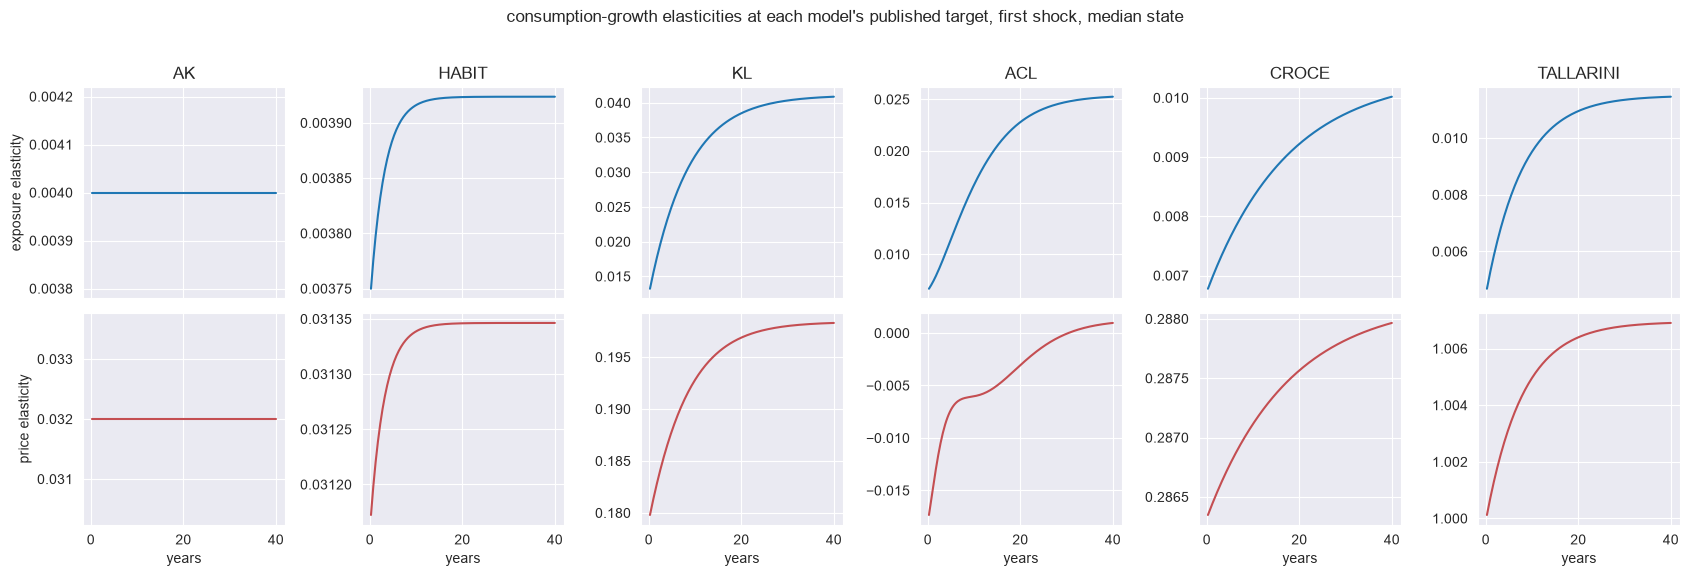

In [6]:
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("darkgrid")
yrs = np.arange(1, T_ELAS + 1) / 4
fig, axes = plt.subplots(2, len(ORDER), figsize=(17, 5.6), sharex=True)
for j, n in enumerate(ORDER):
    if first[n]["solved"]:
        axes[0, j].plot(yrs, first[n]["expo"], lw=1.5)
        axes[1, j].plot(yrs, first[n]["price"], lw=1.5, color="#c44e52")
    axes[0, j].set_title(n)
    axes[1, j].set_xlabel("years")
axes[0, 0].set_ylabel("exposure elasticity")
axes[1, 0].set_ylabel("price elasticity")
fig.suptitle("consumption-growth elasticities at each model's published target, first shock, median state", y=1.02)
fig.tight_layout(); plt.show()

**Reading the results.**

- All six economies solve from automatically derived starting points at their published preference targets — risk aversion up to $\chi = 100$ — and match their papers' own steady-state restrictions at the reported precision (KL to six digits against its closed forms; ACL to $\sim 10^{-10}$ against the Borovička–Hansen chain; the AK and TALLARINI entries reflect the $\rho = 1.001$ convention against $\rho = 1$ closed forms).
- The correlation battery: order 0 is identical, digit for digit, across all $\Sigma$ structures and under rotations (both columns exactly zero), while $|\mu^0|$ moves with the correlations — largest where bad capital shocks bundle with bad long-run news. Elasticity term structures are smooth and settle in every economy.
- Two structural facts about the engine's model class were established while building this notebook and are stated in the Model section: the resource constraint must be of the share form (hence the output-share declarations), and an endogenous labor choice lies outside the current class. Both are exactly the kind of thing an entry layer can check or restate automatically — which is the point of `v2`.